<a href="https://colab.research.google.com/github/ojaspaul123/Projects/blob/main/flight_price_analysis_and_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('flight-price-analysis-and-prediction.csv')
# Display the first few rows of the dataset
df.head()

Saving flight-price-analysis-and-prediction.csv to flight-price-analysis-and-prediction (1).csv


,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


In [19]:
%%markdown
Data Preprocessing

Data Preprocessing


In [20]:
df.isnull().sum()

,0
Airline,0
Source,0
Destination,0
Total_Stops,0
Price,0
Date,0
Month,0
Year,0
Dep_hours,0
Dep_min,0


In [21]:
df.describe()

,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.00000,67.000000
mean,1.000000,7704.746269,15.552239,5.432836,2019.552239,9.686567,21.343284,14.074627,30.298507,4.80597,26.865672
std,0.778499,3226.343602,8.464334,4.268361,0.501017,3.722206,16.823101,3.661071,16.419699,3.21096,13.309709
min,0.000000,2780.000000,1.000000,1.000000,2019.000000,5.000000,0.000000,1.000000,0.000000,1.00000,0.000000
25%,0.000000,4927.500000,8.500000,2.000000,2019.000000,7.000000,10.000000,13.000000,15.000000,2.00000,15.000000
50%,1.000000,7385.000000,16.000000,3.000000,2020.000000,9.000000,20.000000,15.000000,30.000000,4.00000,25.000000
75%,2.000000,10045.000000,22.000000,10.000000,2020.000000,11.000000,30.000000,16.000000,45.000000,8.00000,37.500000
max,2.000000,13882.000000,30.000000,12.000000,2020.000000,22.000000,50.000000,23.000000,55.000000,19.00000,50.000000


In [22]:
%%markdown
Feature Engineering

Feature Engineering


In [23]:
# Create a new column for the full date
df['Full_Date'] = pd.to_datetime(df[['Year', 'Month', 'Date']].rename(columns={'Year': 'year', 'Month': 'month', 'Date': 'day'}))
df.head()

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min,Full_Date
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50,2019-03-24
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25,2019-05-01
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0,2019-06-09
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25,2019-05-12
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45,2019-03-01


In [24]:
%%markdown
Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA)


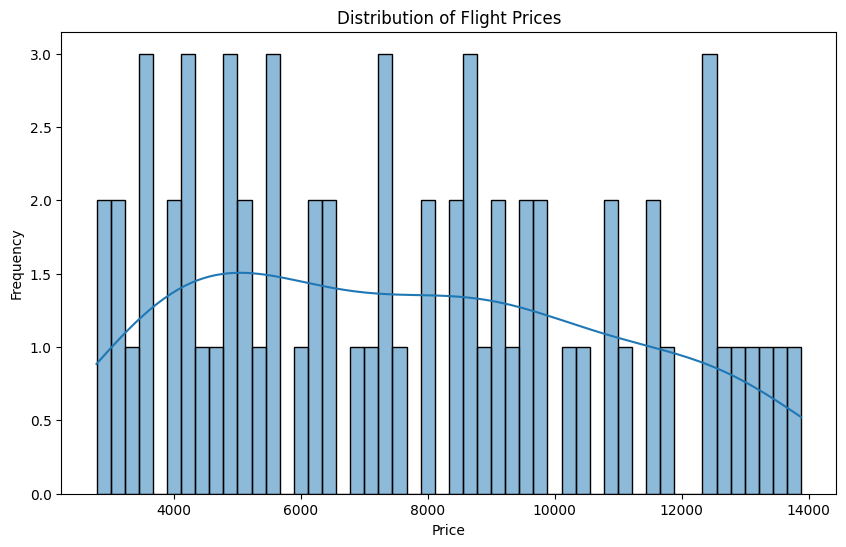

In [25]:
# Distribution of flight prices
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

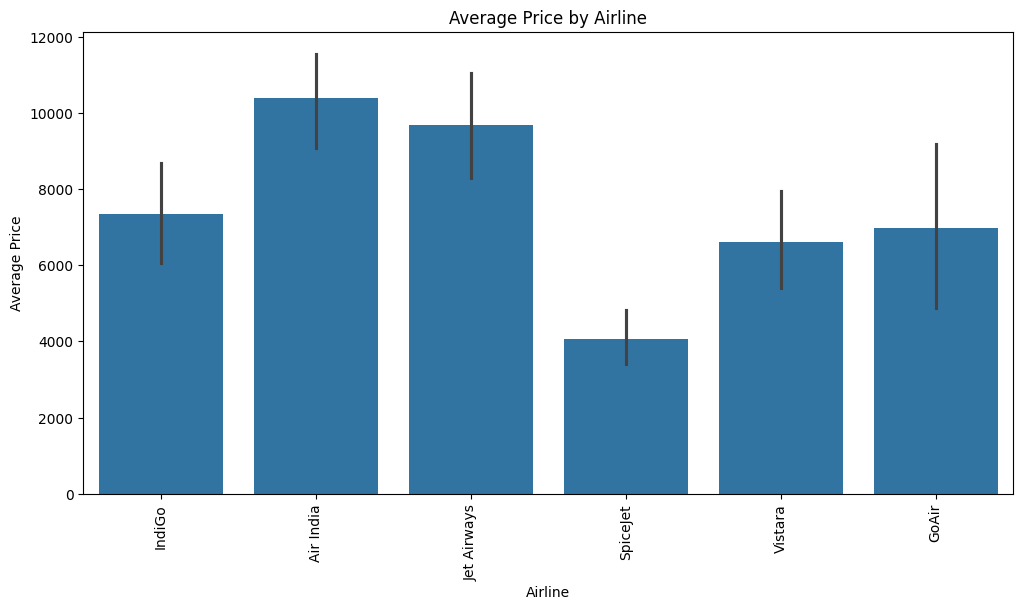

In [26]:
# Average price by airline
plt.figure(figsize=(12, 6))
sns.barplot(x='Airline', y='Price', data=df, estimator=np.mean)
plt.title('Average Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.show()

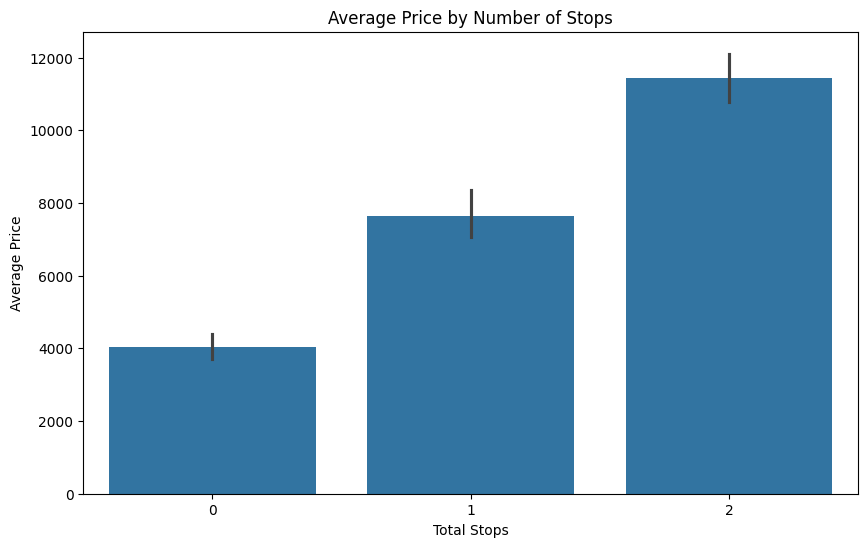

In [27]:
# Average price by number of stops
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Stops', y='Price', data=df, estimator=np.mean)
plt.title('Average Price by Number of Stops')
plt.xlabel('Total Stops')
plt.ylabel('Average Price')
plt.show()